### Read Data

In [43]:
import rasterio
from rasterio.plot import show
import os

# Paths to your files
tif_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/1. Spec_SAR_Data/Stacked_Image_2024_TOA.tif'
txt_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/1. Spec_SAR_Data/2024_TOA Bands Names.txt'
# 1. Read band names from .txt
with open(txt_path, 'r') as f:
    band_names = [line.strip() for line in f.readlines()]

print("✅ Total band names in TXT:", len(band_names))
print("First 10 band names:", band_names[:10])

# 2. Open the .tif file
with rasterio.open(tif_path) as src:
    print("\n🛰 Image Information:")
    print("Width, Height:", src.width, src.height)
    print("Number of Bands:", src.count)
    print("CRS:", src.crs)
    print("Data Type:", src.dtypes[0])
    print("Bounds:", src.bounds)
    
    # Optional: check if bands match
    if len(band_names) != src.count:
        print("⚠️ Warning: Band count mismatch between .tif and .txt")

    # # Optional: read a small preview or show a band
    # band1 = src.read(1)
    # show((src, 1), title="First Band Preview")

✅ Total band names in TXT: 852
First 10 band names: ['VV_20240105', 'VH_20240105', 'B2_20240105', 'B3_20240105', 'B4_20240105', 'B5_20240105', 'B6_20240105', 'B7_20240105', 'B8_20240105', 'B8A_20240105']

🛰 Image Information:
Width, Height: 872 882
Number of Bands: 852
CRS: EPSG:4326
Data Type: float32
Bounds: BoundingBox(left=48.714470047932295, bottom=33.75653242052973, right=48.79280314070752, top=33.83576382858907)


### Divide SAR and optic

In [44]:
import rasterio
from tqdm import tqdm

# Paths
# sar_out_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/1.SAR/2024_SAR_TOA.tif'
spectral_out_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/2.Spectral/2024_Opt_TOA.tif'
tif_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/1. Spec_SAR_Data/Stacked_Image_2024_TOA.tif'
txt_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/1. Spec_SAR_Data/2024_TOA Bands Names.txt'

# Read band names
with open(txt_path, 'r') as f:
    band_names = [line.strip() for line in f.readlines()]

# Identify SAR and Spectral band indices
sar_indices = [i for i, name in enumerate(band_names) if name.startswith('VV_') or name.startswith('VH_')]
spectral_indices = [i for i, name in enumerate(band_names) if name.startswith('B')]

print(f"SAR Bands: {len(sar_indices)} -> {band_names[:5]}")
print(f"Spectral Bands: {len(spectral_indices)} -> {band_names[:5]}")

def write_subset_sequential(band_indices, output_path, description):
    with rasterio.open(tif_path) as src:
        meta = src.meta.copy()
        meta.update({'count': len(band_indices)})

        with rasterio.open(output_path, 'w', **meta) as dst:
            for i, band_index in enumerate(tqdm(band_indices, desc=f"Writing {description} bands")):
                band_data = src.read(band_index + 1)  # rasterio bands are 1-indexed
                dst.write(band_data, i + 1)

# Process SAR bands TIFF
# write_subset_sequential(sar_indices, sar_out_path, "SAR")

# Process Spectral bands TIFF
write_subset_sequential(spectral_indices, spectral_out_path, "Spectral")

print("\n✅ Done splitting SAR and Spectral bands into separate TIFF files.")
# print(f"- SAR image saved at: {sar_out_path}")
print(f"- Spectral image saved at: {spectral_out_path}")

SAR Bands: 122 -> ['VV_20240105', 'VH_20240105', 'B2_20240105', 'B3_20240105', 'B4_20240105']
Spectral Bands: 730 -> ['VV_20240105', 'VH_20240105', 'B2_20240105', 'B3_20240105', 'B4_20240105']


Writing Spectral bands: 100%|██████████| 730/730 [2:12:05<00:00, 10.86s/it]  



✅ Done splitting SAR and Spectral bands into separate TIFF files.
- SAR image saved at: F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/1.SAR/2024_SAR_SR.tif
- Spectral image saved at: F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/2.Spectral/2024_Opt_TOA.tif


In [45]:
import rasterio
from tqdm import tqdm

# Paths
sar_out_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/1.SAR/2018_SAR.tif'
spectral_out_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/2.Spectral/2018_Opt_TOA.tif'
tif_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/1. Spec_SAR_Data/Stacked_Image_2018_TOA.tif'
txt_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/1. Spec_SAR_Data/2018 Bands Names.txt'

# Read band names
with open(txt_path, 'r') as f:
    band_names = [line.strip() for line in f.readlines()]

# Identify SAR and Spectral band indices
sar_indices = [i for i, name in enumerate(band_names) if name.startswith('VV_') or name.startswith('VH_')]
spectral_indices = [i for i, name in enumerate(band_names) if name.startswith('B')]

print(f"SAR Bands: {len(sar_indices)} -> {band_names[:5]}")
print(f"Spectral Bands: {len(spectral_indices)} -> {band_names[:5]}")

def write_subset_sequential(band_indices, output_path, description):
    with rasterio.open(tif_path) as src:
        meta = src.meta.copy()
        meta.update({'count': len(band_indices)})

        with rasterio.open(output_path, 'w', **meta) as dst:
            for i, band_index in enumerate(tqdm(band_indices, desc=f"Writing {description} bands")):
                band_data = src.read(band_index + 1)  # rasterio bands are 1-indexed
                dst.write(band_data, i + 1)

# Process SAR bands TIFF
write_subset_sequential(sar_indices, sar_out_path, "SAR")

# Process Spectral bands TIFF
write_subset_sequential(spectral_indices, spectral_out_path, "Spectral")

print("\n✅ Done splitting SAR and Spectral bands into separate TIFF files.")
print(f"- SAR image saved at: {sar_out_path}")
print(f"- Spectral image saved at: {spectral_out_path}")

SAR Bands: 234 -> ['VV_20180101', 'VH_20180101', 'VV_20180106', 'VH_20180106', 'VV_20180107']
Spectral Bands: 360 -> ['VV_20180101', 'VH_20180101', 'VV_20180106', 'VH_20180106', 'VV_20180107']


Writing Spectral bands: 100%|██████████| 360/360 [48:44<00:00,  8.12s/it]


✅ Done splitting SAR and Spectral bands into separate TIFF files.
- SAR image saved at: F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/1.SAR/2018_SAR.tif
- Spectral image saved at: F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/2.Spectral/2018_Opt_TOA.tif


In [46]:
import rasterio
from tqdm import tqdm

# Paths
sar_out_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/1.SAR/2017_SAR.tif'
spectral_out_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/2.Spectral/2017_Opt_TOA.tif'
tif_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/1. Spec_SAR_Data/Stacked_Image_2017_TOA.tif'
txt_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/1. Spec_SAR_Data/2017 Bands Names.txt'

# Read band names
with open(txt_path, 'r') as f:
    band_names = [line.strip() for line in f.readlines()]

# Identify SAR and Spectral band indices
sar_indices = [i for i, name in enumerate(band_names) if name.startswith('VV_') or name.startswith('VH_')]
spectral_indices = [i for i, name in enumerate(band_names) if name.startswith('B')]

print(f"SAR Bands: {len(sar_indices)} -> {band_names[:5]}")
print(f"Spectral Bands: {len(spectral_indices)} -> {band_names[:5]}")

def write_subset_sequential(band_indices, output_path, description):
    with rasterio.open(tif_path) as src:
        meta = src.meta.copy()
        meta.update({'count': len(band_indices)})

        with rasterio.open(output_path, 'w', **meta) as dst:
            for i, band_index in enumerate(tqdm(band_indices, desc=f"Writing {description} bands")):
                band_data = src.read(band_index + 1)  # rasterio bands are 1-indexed
                dst.write(band_data, i + 1)

# Process SAR bands TIFF
write_subset_sequential(sar_indices, sar_out_path, "SAR")

# Process Spectral bands TIFF
write_subset_sequential(spectral_indices, spectral_out_path, "Spectral")

print("\n✅ Done splitting SAR and Spectral bands into separate TIFF files.")
print(f"- SAR image saved at: {sar_out_path}")
print(f"- Spectral image saved at: {spectral_out_path}")

SAR Bands: 124 -> ['VV_20170210', 'VH_20170210', 'VV_20170211', 'VH_20170211', 'VV_20170222']
Spectral Bands: 250 -> ['VV_20170210', 'VH_20170210', 'VV_20170211', 'VH_20170211', 'VV_20170222']


Writing Spectral bands: 100%|██████████| 250/250 [19:59<00:00,  4.80s/it]


✅ Done splitting SAR and Spectral bands into separate TIFF files.
- SAR image saved at: F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/1.SAR/2017_SAR.tif
- Spectral image saved at: F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/2.Spectral/2017_Opt_TOA.tif


## Plot SAR Annual Data

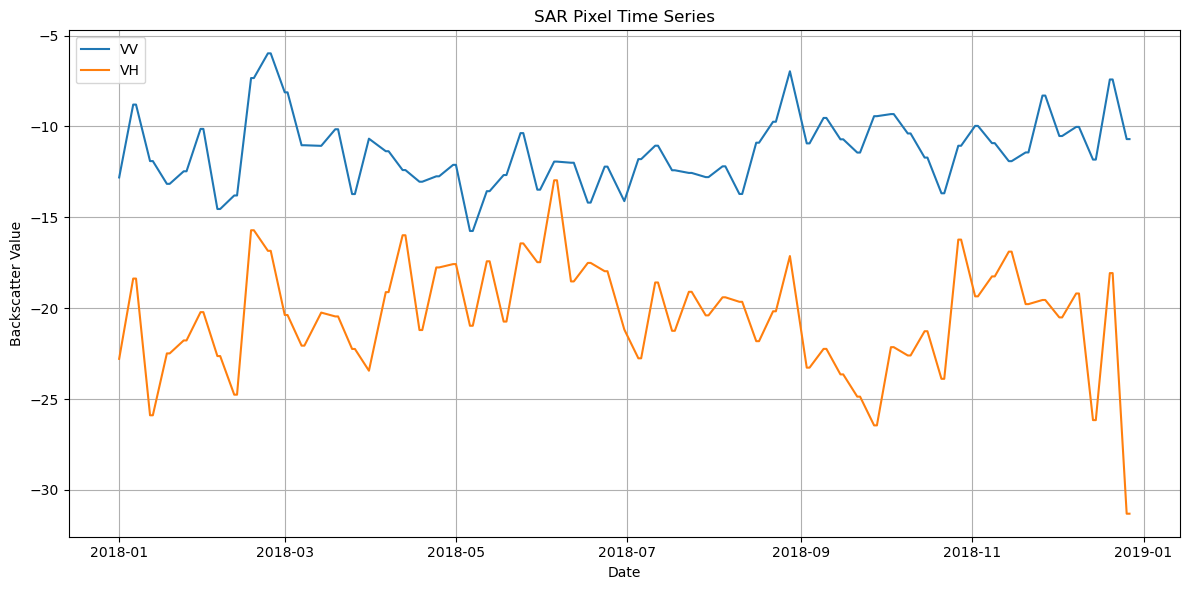

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import rasterio

sar_out_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/1.SAR/2018_SAR.tif'
txt_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/1. Spec_SAR_Data/2018 Bands Names.txt'
# Read band names
with open(txt_path, 'r') as f:
    band_names = [line.strip() for line in f.readlines()]

# Filter only SAR band names and their original indexes
sar_band_info = [(i, name) for i, name in enumerate(band_names) if name.startswith('VV_') or name.startswith('VH_')]

# Extract time series data
dates = []
values = []
polarizations = []

with rasterio.open(sar_out_path) as src:
    height, width = src.height, src.width
    center_row, center_col = height // 2, width // 2

    for band_idx, band_name in enumerate(sar_band_info):
        original_index, full_name = band_name
        date_str = full_name.split('_')[1]
        date = datetime.strptime(date_str, '%Y%m%d')
        pol = full_name.split('_')[0]

        band_data = src.read(band_idx + 1)  # rasterio is 1-indexed
        pixel_value = band_data[center_row, center_col]  # choose a representative pixel
        # OR use: pixel_value = np.nanmean(band_data)

        dates.append(date)
        values.append(pixel_value)
        polarizations.append(pol)

# Create DataFrame
df = pd.DataFrame({
    'date': dates,
    'value': values,
    'polarization': polarizations
})

# Plot
plt.figure(figsize=(12, 6))
for pol in df['polarization'].unique():
    subset = df[df['polarization'] == pol].sort_values('date')
    plt.plot(subset['date'], subset['value'], label=pol)

plt.title('SAR Pixel Time Series')
plt.xlabel('Date')
plt.ylabel('Backscatter Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Plot Optic Annual Data

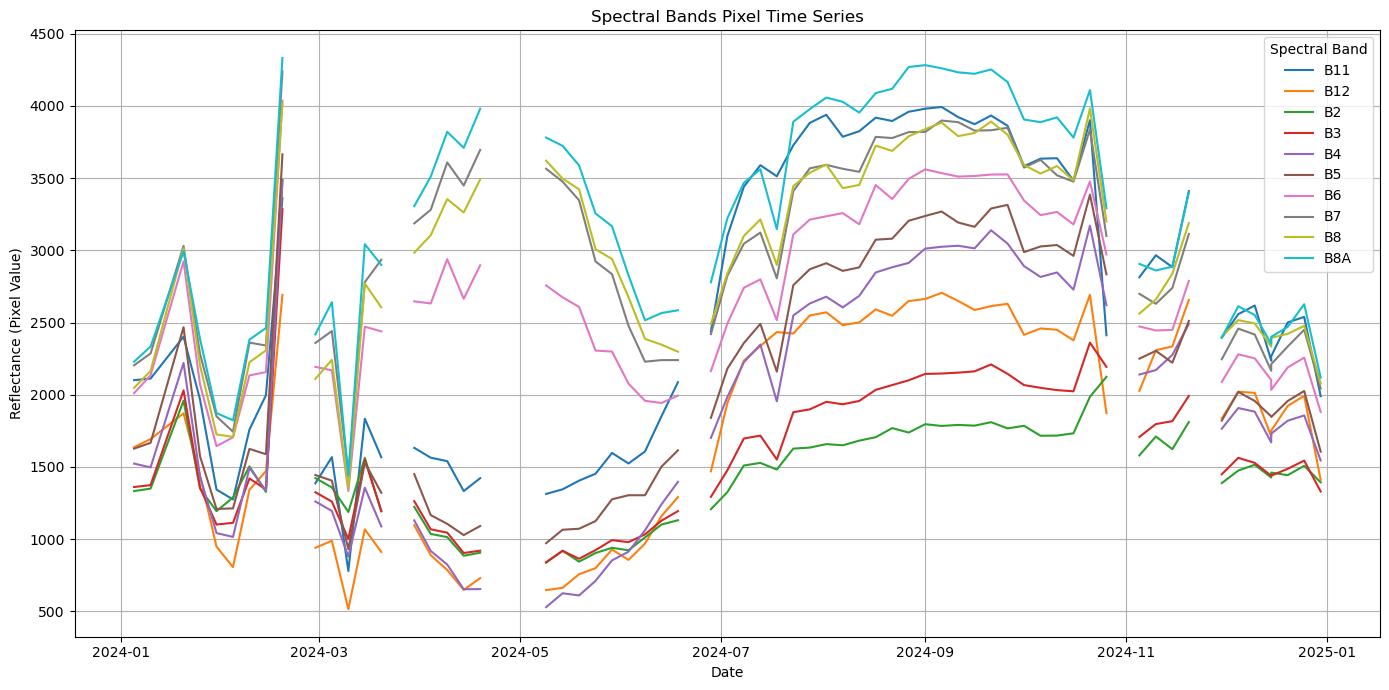

In [6]:
spectral_out_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/2.Spectral/2024_Opt_TOA.tif'
txt_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/1. Spec_SAR_Data/2024_TOA Bands Names.txt'
# Read band names
with open(txt_path, 'r') as f:
    band_names = [line.strip() for line in f.readlines()]

# Filter spectral band names and map to band indices
spectral_band_info = [(i, name) for i, name in enumerate(band_names) if name.startswith('B')]

# Extract time series
dates = []
values = []
bands = []

with rasterio.open(spectral_out_path) as src:
    height, width = src.height, src.width
    row, col = height // 2, width // 2  # pick center pixel

    for idx, (original_index, full_name) in enumerate(spectral_band_info):
        band = full_name.split('_')[0]
        date_str = full_name.split('_')[1]
        date = datetime.strptime(date_str, '%Y%m%d')

        band_data = src.read(idx + 1)  # rasterio is 1-indexed
        pixel_value = band_data[row, col]
        # OR: pixel_value = np.nanmean(band_data)

        dates.append(date)
        values.append(pixel_value)
        bands.append(band)

# Create DataFrame
df = pd.DataFrame({
    'date': dates,
    'value': values,
    'band': bands
})

# Plot time series for each band
plt.figure(figsize=(14, 7))
for band in sorted(df['band'].unique()):
    subset = df[df['band'] == band].sort_values('date')
    plt.plot(subset['date'], subset['value'], label=band)

plt.title('Spectral Bands Pixel Time Series')
plt.xlabel('Date')
plt.ylabel('Reflectance (Pixel Value)')
plt.legend(title='Spectral Band')
plt.grid(True)
plt.tight_layout()
plt.show()

## VI Extraction

Total bands: 730, Dates: 73, Image size: 872x882


Processing dates:  12%|█▏        | 9/73 [00:29<01:16,  1.19s/it]C:\Users\mamad_js\AppData\Local\Temp\ipykernel_21052\2156463007.py:94: RuntimeWarning: Mean of empty slice
  avg_value = np.nanmean(vi_data)
Processing dates:  18%|█▊        | 13/73 [00:50<02:46,  2.77s/it]C:\Users\mamad_js\AppData\Local\Temp\ipykernel_21052\2156463007.py:22: RuntimeWarning: divide by zero encountered in divide
  indices['EVI'] = 2.5 * ((nir - red) / (nir + 6 * red - 7.5 * blue + 1))
Processing dates: 100%|██████████| 73/73 [03:21<00:00,  2.76s/it]



✅ Vegetation indices calculated and saved!


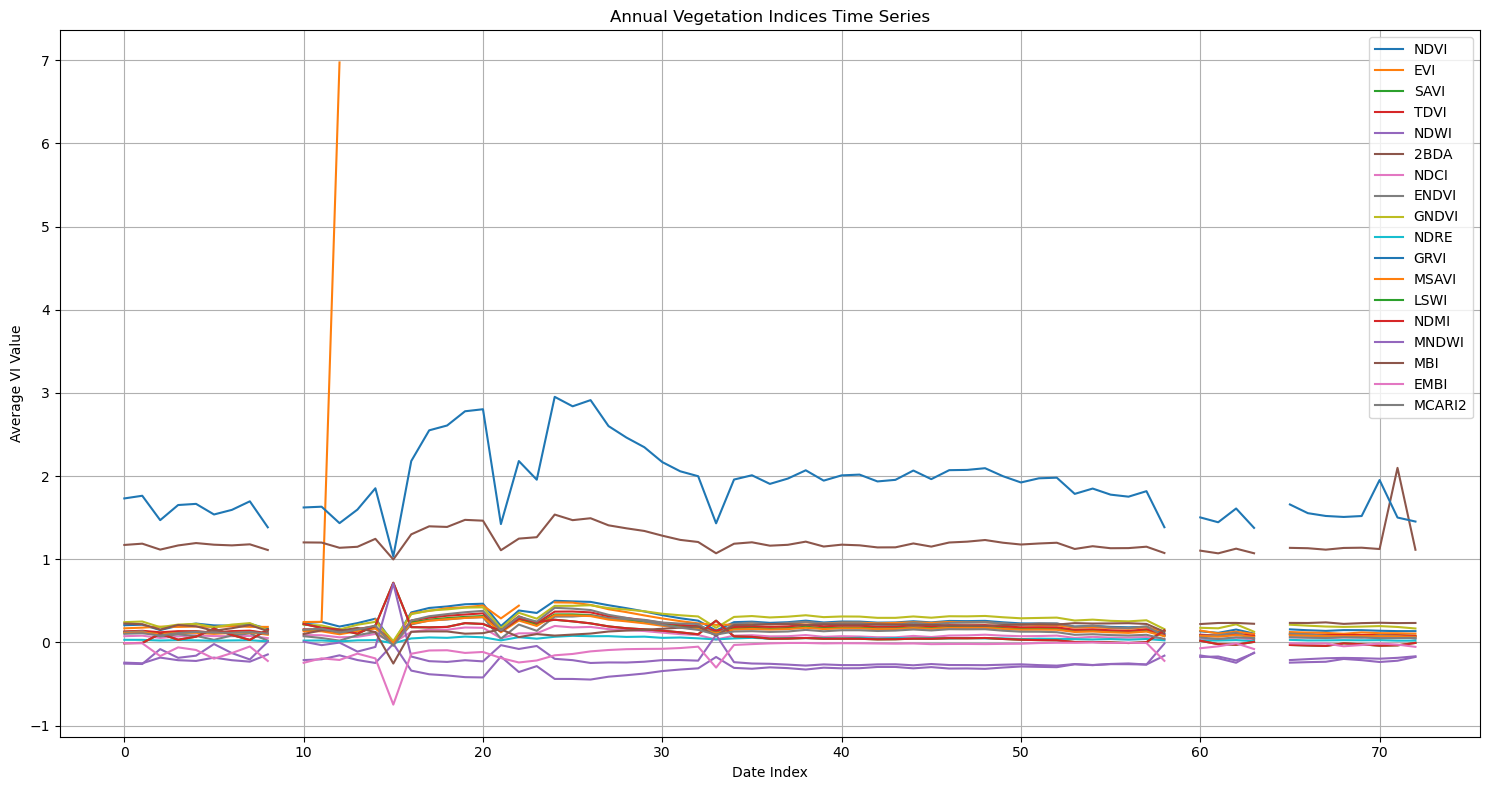

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# === Your VI calculator function ===
def calculate_all_indices(image_data):
    indices = {}
    blue = image_data[0] / 10000
    green = image_data[1] / 10000
    red = image_data[2] / 10000
    red_edge1 = image_data[3] / 10000
    red_edge2 = image_data[4] / 10000
    red_edge3 = image_data[5] / 10000
    nir = image_data[6] / 10000
    red_edge4 = image_data[7] / 10000
    swir1 = image_data[8] / 10000
    swir2 = image_data[9] / 10000
    L = 0.5

    indices['NDVI'] = (nir - red) / (nir + red + 1e-6)
    indices['EVI'] = 2.5 * ((nir - red) / (nir + 6 * red - 7.5 * blue + 1))
    indices['SAVI'] = ((nir - red) / (nir + red + L)) * (1 + L)
    indices['TDVI'] = 1.5 * ((nir - red) / np.sqrt((nir ** 2 + red + 0.5)))
    indices['NDWI'] = (green - nir) / (green + nir + 1e-6)
    indices['2BDA'] = red_edge1 / (red + 1e-6)
    indices['NDCI'] = (red_edge1 - red) / (red_edge1 + red + 1e-6)
    indices['ENDVI'] = ((nir + green) - 2 * blue) / ((nir + green) + 2 * blue + 1e-6)
    indices['GNDVI'] = (nir - green) / (nir + green + 1e-6)
    indices['NDRE'] = (nir - red_edge2) / (nir + red_edge2 + 1e-6)
    indices['GRVI'] = nir / (green + 1e-6)
    indices['MSAVI'] = (2 * nir + 1 - np.sqrt((2 * nir + 1) ** 2 - 8 * (nir - red))) / 2
    indices['LSWI'] = (nir - swir1) / (nir + swir1 + 1e-6)
    indices['NDMI'] = (nir - swir1) / (nir + swir1 + 1e-6)
    indices['MNDWI'] = (green - swir1) / (green + swir1 + 1e-6)
    indices['MBI'] = ((swir1 - swir2 - nir) / (swir1 + swir2 + nir + 1e-6)) + 0.5
    indices['EMBI'] = (indices['MBI'] - indices['MNDWI'] - 0.5) / (indices['MBI'] + indices['MNDWI'] + 1.5)
    indices['MCARI2'] = 1.5 * (2.5 * (nir - red) - 1.3 * (nir - green)) / (
        np.sqrt((2 * nir + 1) ** 2 - (6 * nir - 5 * np.sqrt(red + 1e-6))) - 0.5
    )
    return indices

# Paths
spectral_tif_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/2.Spectral/2024_Opt_TOA.tif'
output_vi_tif_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/3.VIs/2024_VIs_TOA.tif'

with rasterio.open(spectral_tif_path) as src:
    meta = src.meta.copy()
    total_bands = src.count
    width, height = src.width, src.height
    
    # Number of dates
    bands_per_date = 10
    n_dates = total_bands // bands_per_date
    
    print(f"Total bands: {total_bands}, Dates: {n_dates}, Image size: {width}x{height}")
    
    # List of VI names in order
    vi_names = list(calculate_all_indices(np.zeros((bands_per_date, 1, 1))).keys())
    n_vis = len(vi_names)
    
    # Prepare output meta: number of bands = n_dates * n_vis
    meta.update({
        'count': n_dates * n_vis,
        'dtype': 'float32',
        'driver': 'GTiff',
        'compress': 'lzw'
    })
    
    # Initialize container to hold average VI per date for plotting
    avg_vi_per_date = {vi: [] for vi in vi_names}
    
    with rasterio.open(output_vi_tif_path, 'w', **meta) as dst:
        band_number = 1  # output band index
        
        for date_idx in tqdm(range(n_dates), desc="Processing dates"):
            # Read 10 bands for current date
            bands_start = date_idx * bands_per_date + 1
            bands_end = bands_start + bands_per_date - 1
            
            image_data = src.read(list(range(bands_start, bands_end + 1)))  # shape (10, H, W)
            
            # Calculate all indices
            indices = calculate_all_indices(image_data)
            
            # For each VI, write to output TIFF and store average for plot
            for vi in vi_names:
                vi_data = indices[vi].astype(np.float32)
                
                dst.write(vi_data, band_number)
                band_number += 1
                
                # Average VI over whole image (skip nan values)
                avg_value = np.nanmean(vi_data)
                avg_vi_per_date[vi].append(avg_value)

print("\n✅ Vegetation indices calculated and saved!")

# Plot time series for all VIs
plt.figure(figsize=(15, 8))
for vi in vi_names:
    plt.plot(avg_vi_per_date[vi], label=vi)

plt.title('Annual Vegetation Indices Time Series')
plt.xlabel('Date Index')
plt.ylabel('Average VI Value')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


## Save B8s for GLCM

In [6]:
import rasterio
import numpy as np
from tqdm import tqdm

# Input and output paths
spectral_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/2.Spectral/2024_Opt_TOA.tif'
b8_output_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/4.NIR_Band/2024_B8_TOA.tif'

# Open spectral stack
with rasterio.open(spectral_path) as src:
    meta = src.meta.copy()
    total_bands = src.count
    width, height = src.width, src.height

    bands_per_date = 10
    n_dates = total_bands // bands_per_date
    print(f"Total bands: {total_bands}, Dates: {n_dates}")

    # Update metadata for output: one band per date
    meta.update({
        'count': n_dates,
        'dtype': 'float32',
        'compress': 'lzw'
    })

    with rasterio.open(b8_output_path, 'w', **meta) as dst:
        for i in tqdm(range(n_dates), desc='Extracting B8'):
            b8_band_index = i * bands_per_date + 7  # 1-indexed band number
            b8_data = src.read(b8_band_index).astype(np.float32) / 10000  # optional scaling
            dst.write(b8_data, i + 1)

print(f"\n✅ B8 extraction complete. Saved at:\n{b8_output_path}")

Total bands: 730, Dates: 73


Extracting B8: 100%|██████████| 73/73 [00:33<00:00,  2.16it/s]


✅ B8 extraction complete. Saved at:
F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/4.NIR_Band/2024_B8_TOA.tif


## Now NDVIs for Phenology

In [11]:
import rasterio
import numpy as np
from tqdm import tqdm

# Input spectral image path
spectral_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/2.Spectral/2018_Opt_TOA.tif'
ndvi_out_path = 'F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/7.Pheonlogy/2018_NDVI.tif'

# Constants
bands_per_date = 10
nir_index = 6  # B8
red_index = 2  # B4

# Read and process
with rasterio.open(spectral_path) as src:
    meta = src.meta.copy()
    total_bands = src.count
    n_dates = total_bands // bands_per_date
    height, width = src.height, src.width

    # Update metadata for NDVI output
    meta.update({
        'count': n_dates,
        'dtype': 'float32',
        'compress': 'lzw'
    })

    with rasterio.open(ndvi_out_path, 'w', **meta) as dst:
        for i in tqdm(range(n_dates), desc='Computing NDVI'):
            # 1-based indexing for rasterio
            red_band = src.read(i * bands_per_date + red_index + 1).astype(np.float32) / 10000
            nir_band = src.read(i * bands_per_date + nir_index + 1).astype(np.float32) / 10000

            ndvi = (nir_band - red_band) / (nir_band + red_band + 1e-6)
            dst.write(ndvi.astype(np.float32), i + 1)

print(f"\n✅ NDVI time series saved as multi-band image at:\n{ndvi_out_path}")

Computing NDVI: 100%|██████████| 36/36 [00:28<00:00,  1.28it/s]



✅ NDVI time series saved as multi-band image at:
F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/7.Pheonlogy/2018_NDVI.tif
